In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      1
    Core(s) per socket:      96
    Socket(s):               2
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      74%
    CPU max MHz:             3715.4290
    CPU min MHz:             1500.0000
    BogoMIPS:                5100.07
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from scipy.optimize import fmin, minimize, LinearConstraint, Bounds

from efficient_fpt.cython.batch import (
    compute_addm_nll,
    compute_tada_mean_nll,
)

import sys, os

In [3]:
combined_pkl = "addm_data_all_kappa_20260220-230703.pkl"  # <-- adjust filename as needed

with open(combined_pkl, "rb") as f:
    all_data = pickle.load(f)
data_keys = sorted(all_data.keys())
print(f"Loaded combined pkl with {len(data_keys)} eta values: {data_keys}")

Loaded combined pkl with 10 eta values: [0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7000000000000001, 0.8, 0.9, 1.0]


/tmp/ipykernel_1053790/1134421968.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  all_data = pickle.load(f)


In [4]:
num_data_list = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]

### Run maximum likelihood with aDDM likelihood function with different dataset size

In [8]:
paras_true_arr = np.zeros((len(num_data_list), len(data_keys), 4))
paras_mle_arr = np.zeros((len(num_data_list), len(data_keys), 4))

for i, data_name in enumerate(data_keys):
    for j, num_data in enumerate(num_data_list):
        data = all_data[data_name]
        a = data["a"]
        b = data["b"]
        x0 = data["x0"]
        eta_true = data["eta"]
        kappa_true = data["kappa"]
        r1_data = data["r1_data"][:num_data].astype(np.float64)
        r2_data = data["r2_data"][:num_data].astype(np.float64)
        flag_data = data["flag_data"][:num_data].astype(np.int32)
        sacc_data = data["sacc_array_padded_data"][:num_data, :].astype(np.float64)
        num_data, max_d = sacc_data.shape
        sigma = data["sigma"]
        T = data["T"]
        length_data = data["d_data"][:num_data].astype(np.int32)
        rt_data = data["decision_data"][:num_data, 0].astype(np.float64)
        choice_data = data["decision_data"][:num_data, 1].astype(np.int32)

        if j == 0:
            print(f"true params: [{eta_true:.2f}, {kappa_true:.2f}, {a:.2f}, {x0:.2f}]")

        # print("\nNumerical optimization for eta:")
        method = "trust-constr"
        # print("Using " + method)
        func = lambda paras: compute_addm_nll(
            rt_data,
            choice_data,
            paras[0], paras[1], sigma, paras[2], b, paras[3],
            r1_data, r2_data, flag_data,
            sacc_data, length_data,
            order_mid=30,
            order_last=30,
            n_threads=-1, reduce="mean", invalid_policy="warn", warn="False",
            # n_threads=-1, log_space=True, reduce="mean",
        )
        bounds = Bounds([0, 0, 0, -np.inf], [1, np.inf, np.inf, np.inf]) #, keep_feasible=[True, True, True, True])
        con = LinearConstraint(
            [[0, 0, 1, 1], [0, 0, 1, -1]],
            lb=[0, 0],
            ub=[np.inf, np.inf],
            # keep_feasible=True,
        )
        initial_guess = [0.5, 0.5, 1.0, 0.0]
        # print("Initial guess:", initial_guess)
        # print()
        start_time = time.time()
        paras_opt_result = minimize(
            func,
            x0=initial_guess,
            bounds=bounds,
            constraints=con,
            method=method,
            options={"verbose": 0},
        )
        # print(f"Total time: {time.time() - start_time:.3f} seconds")
        if not paras_opt_result.success:
            print(f"WARNING: eta={eta_true} optimization failed.")
        mle = paras_opt_result["x"]
        paras_true_arr[j, i] = np.array([eta_true, kappa_true, a, x0])
        paras_mle_arr[j, i] = mle
        print(
            f"num_data: {num_data:5d},",
            f"mle: [{', '.join(f'{x:.5f}' for x in mle)}]",
        )

    print()

# true params: [0.30, 0.10, 2.00, 0.50]
# num_data:   100, mle: [0.73475, 0.16052, 2.21876, 0.68811]
# num_data:   200, mle: [0.91078, 0.12731, 2.11416, 0.58723]
# num_data:   400, mle: [0.43930, 0.12361, 2.02637, 0.45310]
# num_data:   800, mle: [0.48319, 0.11611, 2.05541, 0.50899]
# num_data:  1600, mle: [0.35399, 0.10609, 2.01744, 0.52243]
# num_data:  3200, mle: [0.31046, 0.10850, 2.01377, 0.53254]
# num_data:  6400, mle: [0.32565, 0.10033, 2.00261, 0.51455]
# num_data: 12800, mle: [0.29240, 0.10222, 2.00148, 0.50558]
# num_data: 25600, mle: [0.29977, 0.10364, 2.00680, 0.50621]

true params: [0.30, 0.10, 2.00, 0.50]
num_data:   100, mle: [0.73475, 0.16052, 2.21876, 0.68811]


/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


num_data:   200, mle: [0.91080, 0.12731, 2.11416, 0.58723]


/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


num_data:   400, mle: [0.43930, 0.12361, 2.02637, 0.45310]


...

num_data: 25600, mle: [0.29745, 0.90187, 2.00510, 0.49739]

true params: [0.30, 1.00, 2.00, 0.50]
num_data:   100, mle: [0.37585, 0.95672, 1.92389, 0.51279]
num_data:   200, mle: [0.32798, 0.90973, 1.90833, 0.51813]
num_data:   400, mle: [0.29989, 0.94748, 1.94793, 0.53520]


/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


num_data:   800, mle: [0.29626, 0.96022, 1.93776, 0.51936]
num_data:  1600, mle: [0.29840, 0.97837, 1.99124, 0.52874]
num_data:  3200, mle: [0.30572, 0.97366, 1.98671, 0.52369]
num_data:  6400, mle: [0.29372, 0.99457, 1.98823, 0.50724]


/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


num_data: 12800, mle: [0.29544, 0.99070, 1.98013, 0.49574]
num_data: 25600, mle: [0.30044, 0.99117, 1.98930, 0.50133]



### Run maximum likelihood with TADA likelihood function with different dataset size

In [14]:
paras_true_arr = np.zeros((len(num_data_list), len(data_keys), 4))
paras_tada_arr = np.zeros((len(num_data_list), len(data_keys), 4))

for i, data_name in enumerate(data_keys):
    for j, num_data in enumerate(num_data_list):
        data = all_data[data_name]
        a = data["a"]
        b = data["b"]
        x0 = data["x0"]
        eta_true = data["eta"]
        kappa_true = data["kappa"]
        r1_data = data["r1_data"][:num_data].astype(np.float64)
        r2_data = data["r2_data"][:num_data].astype(np.float64)
        flag_data = data["flag_data"][:num_data].astype(np.int32)
        sacc_data = data["sacc_array_padded_data"][:num_data, :].astype(np.float64)
        num_data, max_d = sacc_data.shape
        sigma = data["sigma"]
        T = data["T"]
        length_data = data["d_data"][:num_data].astype(np.int32)
        rt_data = data["decision_data"][:num_data, 0].astype(np.float64)
        choice_data = data["decision_data"][:num_data, 1].astype(np.int32)

        if j == 0:
            print(f"true params: [{eta_true:.2f}, {kappa_true:.2f}, {a:.2f}, {x0:.2f}]")

        # print("\nNumerical optimization for eta:")
        method = "trust-constr"
        # print("Using " + method)
        func = lambda paras: compute_tada_mean_nll(
            rt_data,
            choice_data,
            paras[0], paras[1], sigma, paras[2], b, paras[3],
            r1_data, r2_data, flag_data,
            sacc_data, length_data,
            n_threads=-1, invalid_policy="warn",
        )
        bounds = Bounds([-np.inf, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf], keep_feasible=[True, True, True, True])
        con = LinearConstraint(
            [[0, 0, 1, 1], [0, 0, 1, -1]],
            lb=[0, 0],
            ub=[np.inf, np.inf],
            keep_feasible=True,
        )
        initial_guess = [0.5, 0.5, 1.0, 0.0]
        # print("Initial guess:", initial_guess)
        # print()
        start_time = time.time()
        paras_opt_result = minimize(
            func,
            x0=initial_guess,
            bounds=bounds,
            constraints=con,
            method=method,
            options={"verbose": 0},
        )
        # print(f"Total time: {time.time() - start_time:.3f} seconds")
        if not paras_opt_result.success:
            print(f"WARNING: eta={eta_true} optimization failed.")
        mle = paras_opt_result["x"]
        paras_true_arr[j, i] = np.array([eta_true, kappa_true, a, x0])
        paras_tada_arr[j, i] = mle
        print(
            f"num_data: {num_data:5d}, "
            f"tada mle: [{', '.join(f'{x:.5f}' for x in mle)}]"
        )
    print()

# true params: [0.30, 0.10, 2.00, 0.50]
# num_data:   100, tada mle: [1.18412, 0.13329, 2.22017, 0.70107]
# num_data:   200, tada mle: [0.99520, 0.12267, 2.11387, 0.58778]
# num_data:   400, tada mle: [0.34242, 0.13184, 2.02226, 0.45333]
# num_data:   800, tada mle: [0.36057, 0.12619, 2.05327, 0.51066]
# num_data:  1600, tada mle: [0.18673, 0.12060, 2.01530, 0.52319]
# num_data:  3200, tada mle: [0.13815, 0.12501, 2.01110, 0.53077]
# num_data:  6400, tada mle: [0.16999, 0.11392, 1.99996, 0.51321]
# num_data: 12800, tada mle: [0.15467, 0.11481, 1.99832, 0.50336]
# num_data: 25600, tada mle: [0.18939, 0.11347, 2.00308, 0.50358]

true params: [0.30, 0.10, 2.00, 0.50]
num_data:   100, tada mle: [1.18412, 0.13329, 2.22017, 0.70107]
num_data:   200, tada mle: [0.99520, 0.12267, 2.11387, 0.58778]
num_data:   400, tada mle: [0.34242, 0.13184, 2.02226, 0.45333]
num_data:   800, tada mle: [0.36057, 0.12619, 2.05327, 0.51066]


/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


num_data:  1600, tada mle: [0.18673, 0.12060, 2.01530, 0.52319]


/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


num_data:  3200, tada mle: [0.13815, 0.12501, 2.01110, 0.53077]
num_data:  6400, tada mle: [0.16999, 0.11392, 1.99996, 0.51321]
num_data: 12800, tada mle: [0.15467, 0.11481, 1.99832, 0.50336]
num_data: 25600, tada mle: [0.18938, 0.11347, 2.00308, 0.50358]

true params: [0.30, 0.20, 2.00, 0.50]
num_data:   100, tada mle: [0.19221, 0.30686, 2.10353, 0.58539]
num_data:   200, tada mle: [0.23653, 0.24905, 2.04021, 0.59326]
num_data:   400, tada mle: [0.37315, 0.23177, 2.00115, 0.53017]
num_data:   800, tada mle: [0.21332, 0.22262, 1.97813, 0.50381]


/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:20: RuntimeWarning: trial 574 outputs -inf log-likelihood
  fx = fun(np.copy(x), *args)
/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:20: RuntimeWarning: trial 828 outputs -inf log-likelihood
  fx = fun(np.copy(x), *args)
/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:20: RuntimeWarning: trial 1271 outputs -inf log-likelihood
  fx = fun(np.copy(x), *args)


num_data:  1600, tada mle: [0.26797, 0.33386, 1.00000, 0.00000]
num_data:  3200, tada mle: [0.37990, 0.23980, 0.97095, 0.01585]
num_data:  6400, tada mle: [0.21056, 0.21465, 2.00415, 0.51838]
num_data: 12800, tada mle: [0.18399, 0.21562, 2.00332, 0.50951]
num_data: 25600, tada mle: [0.17093, 0.21954, 1.99596, 0.49988]

true params: [0.30, 0.30, 2.00, 0.50]
num_data:   100, tada mle: [0.14672, 0.39650, 2.17211, 0.54848]
num_data:   200, tada mle: [0.18928, 0.35316, 2.02841, 0.48999]
num_data:   400, tada mle: [0.15878, 0.35415, 2.01022, 0.50465]
num_data:   800, tada mle: [0.14986, 0.33100, 2.00650, 0.50543]
num_data:  1600, tada mle: [0.16019, 0.32909, 1.97909, 0.49187]
num_data:  3200, tada mle: [0.14368, 0.34255, 1.98818, 0.48734]
num_data:  6400, tada mle: [0.13849, 0.33820, 1.97654, 0.49174]
num_data: 12800, tada mle: [0.13124, 0.34049, 1.98610, 0.49322]
num_data: 25600, tada mle: [0.14103, 0.34253, 1.98856, 0.48968]

true params: [0.30, 0.40, 2.00, 0.50]
num_data:   100, tada mle:

In [7]:
# save results

data_to_save = {
    "paras_true_arr": paras_true_arr,
    "paras_mle_arr": paras_mle_arr,
    "paras_tada_arr": paras_tada_arr,
}
fname = "tada_mle_result_" + time.strftime("%Y%m%d-%H%M%S") + ".pkl"

with open(fname, "wb") as f:
    pickle.dump(data_to_save, f)

In [8]:
# load results (if necessary)

results = pickle.load(open("tada_mle_result_20260221-111119.pkl", "rb")) # <-- adjust filename as needed
paras_true_arr = results["paras_true_arr"]
paras_mle_arr = results["paras_mle_arr"]
paras_tada_arr = results["paras_tada_arr"]

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import os

if "/oscar/home/sliu167/texlive/2024/bin/x86_64-linux" not in os.environ["PATH"]:
    os.environ["PATH"] = (
        "/oscar/home/sliu167/texlive/2024/bin/x86_64-linux:" + os.environ["PATH"]
    )

mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amsfonts}"

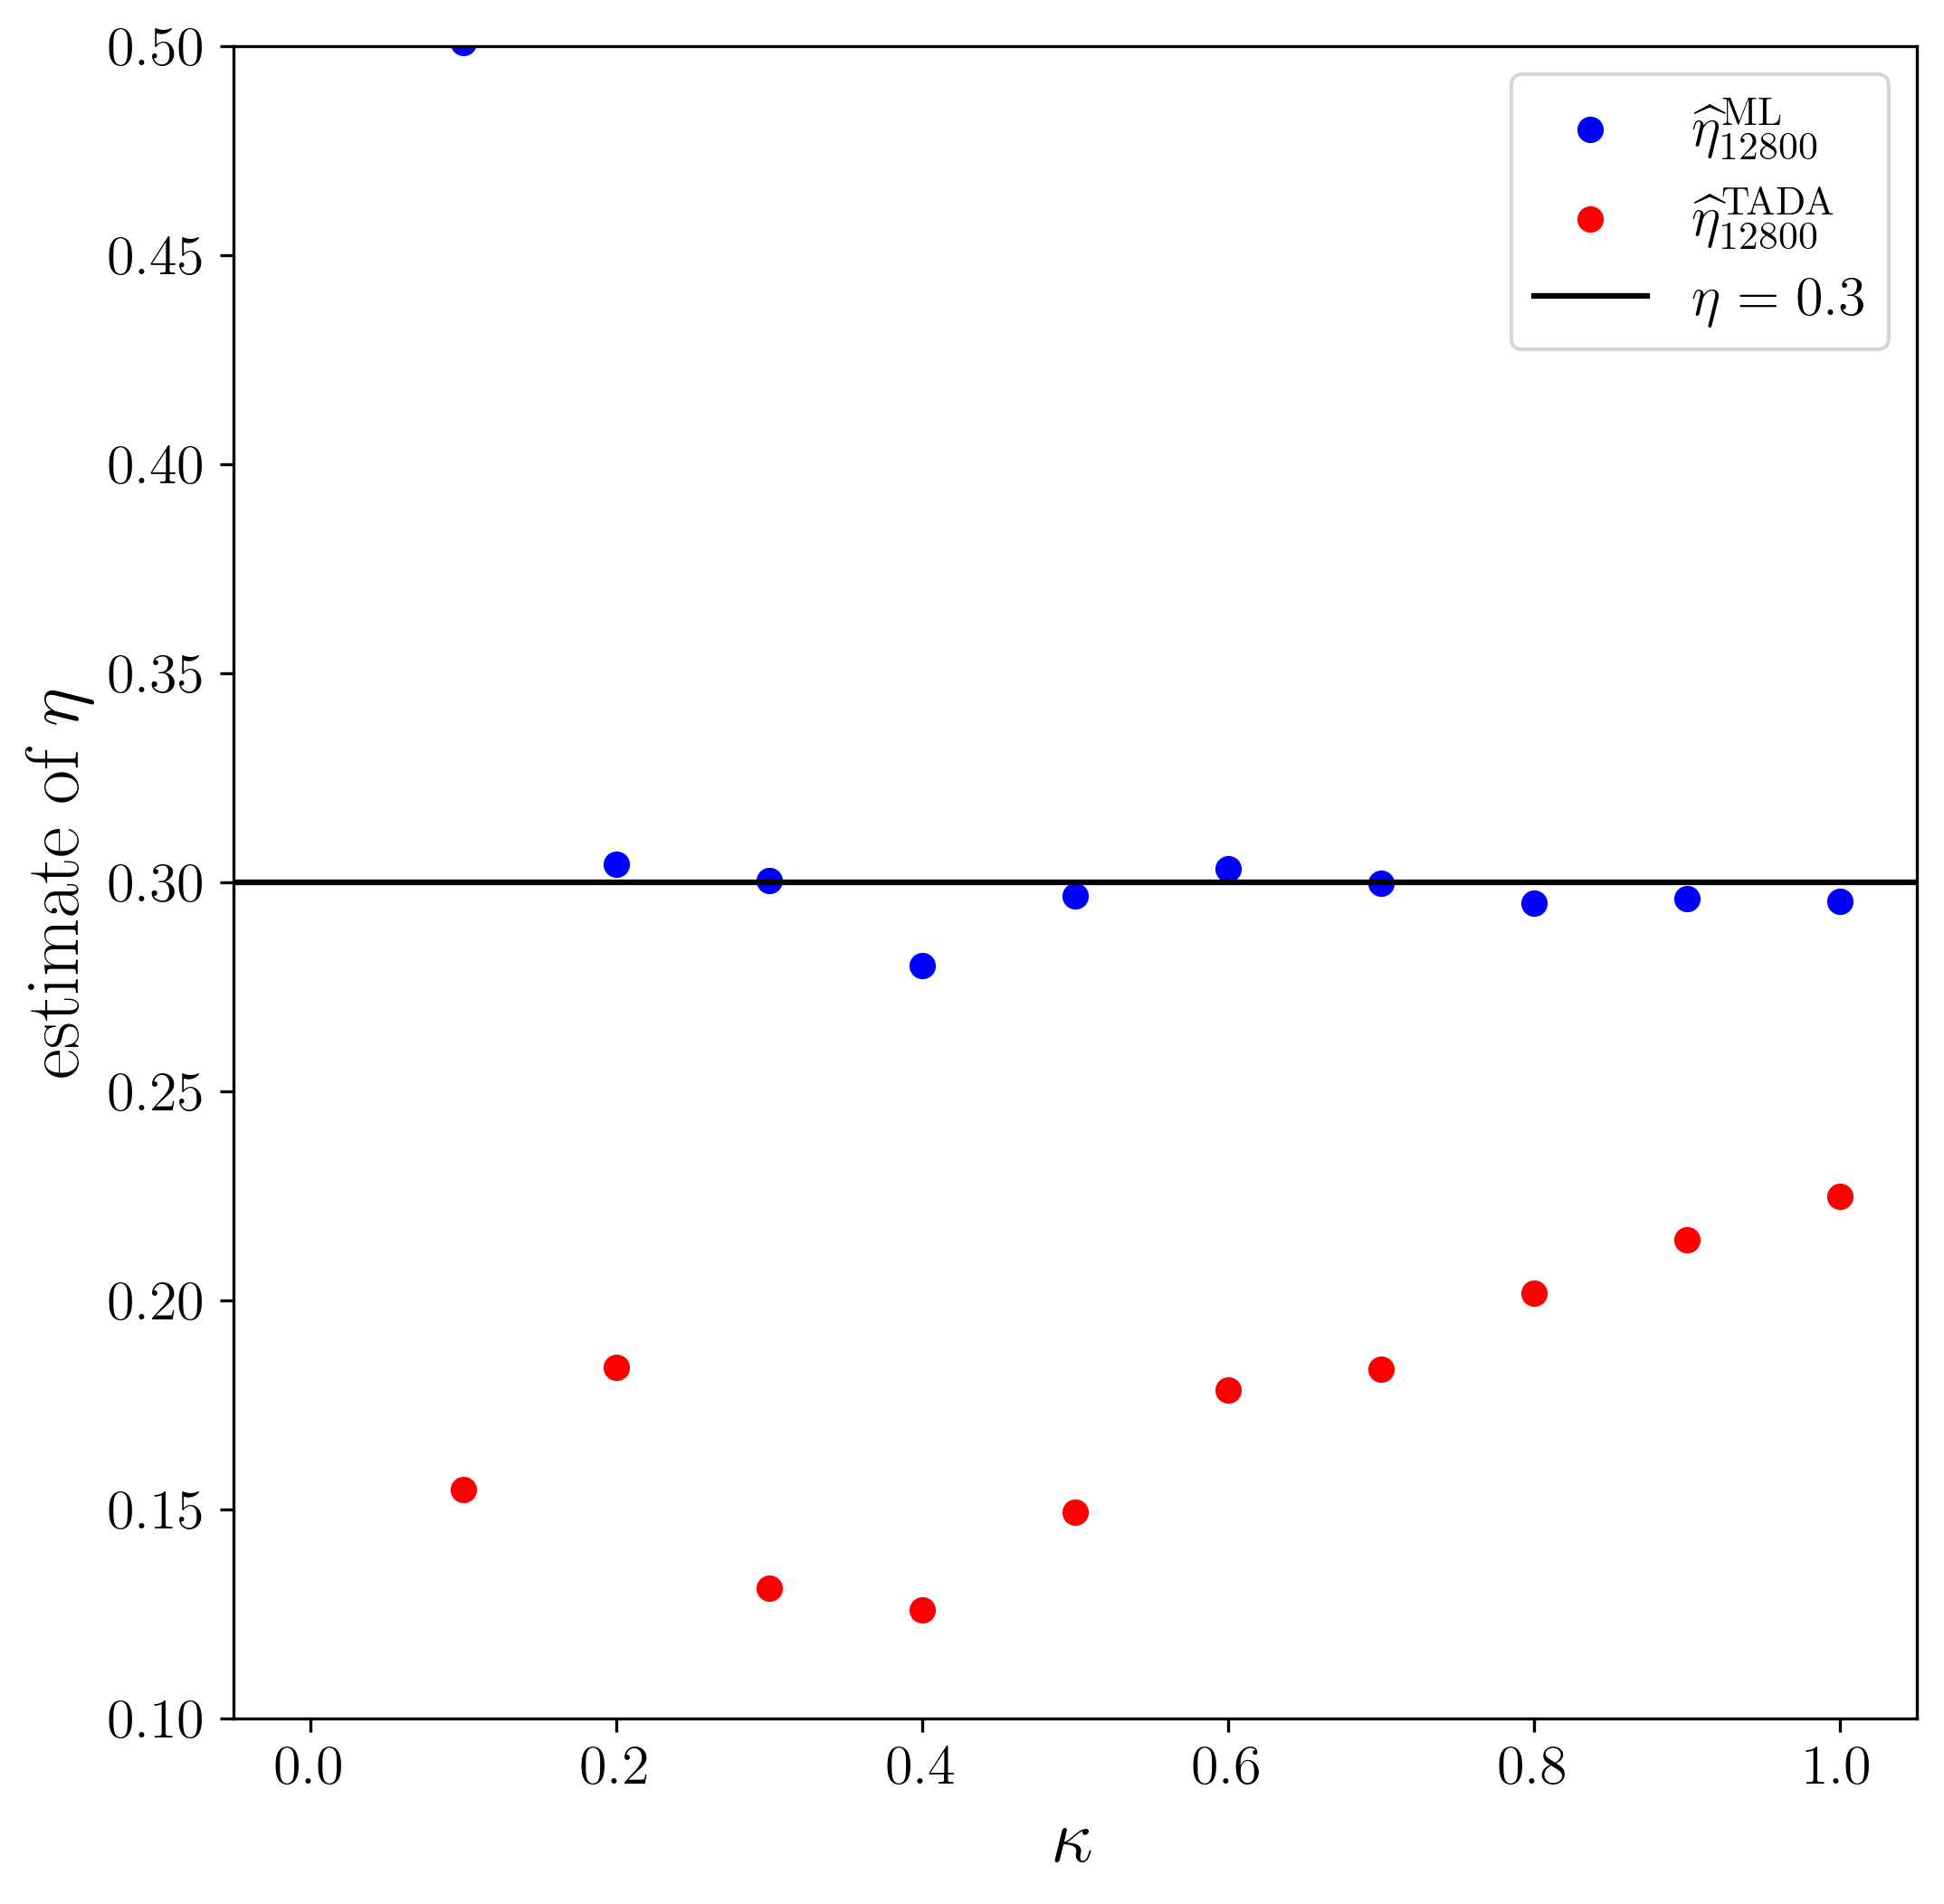

In [16]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_mle_arr[num_data_idx, :, 0],
    label=rf"$\widehat{{\eta}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_tada_arr[num_data_idx, :, 0],
    label=rf"$\widehat{{\eta}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 0], 0, 1, c="k", label=rf"$\eta={paras_true_arr[num_data_idx, 0, 0]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$\kappa$", fontsize=20)
ax.set_ylabel(r"estimate of $\eta$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-0.05, 1.05))
ax.set_ylim((0.1, 0.5))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

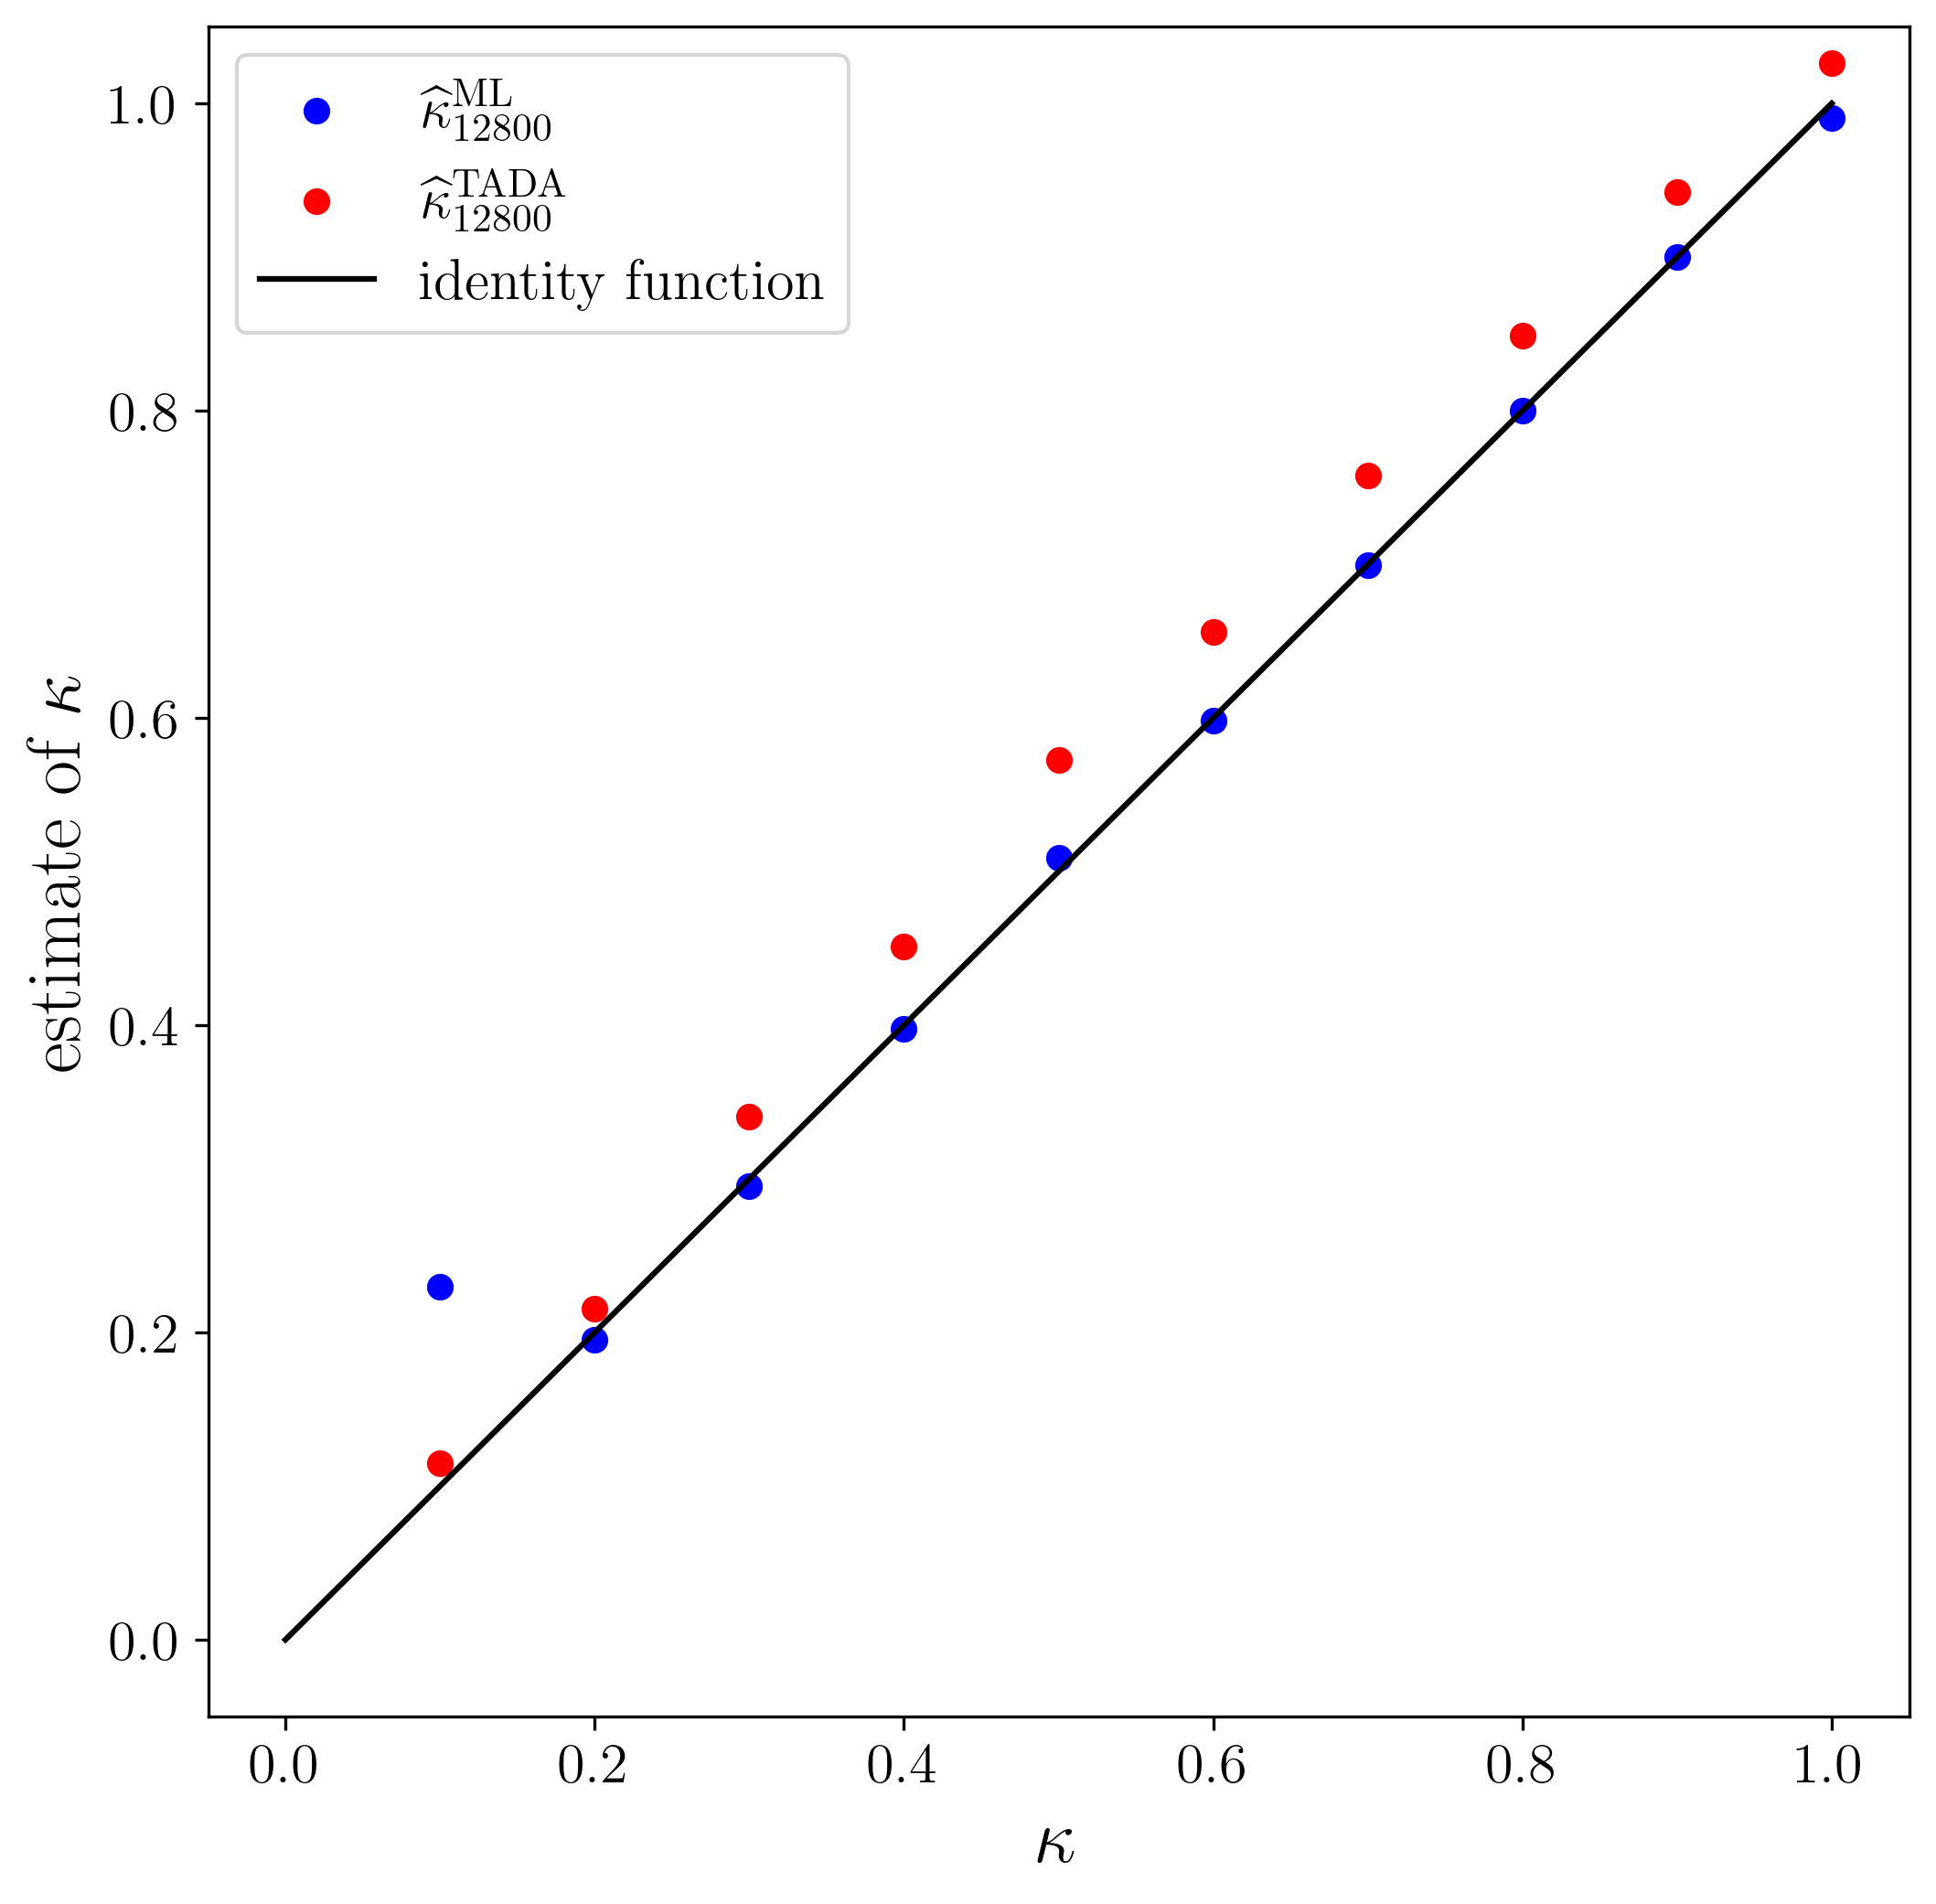

In [17]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_mle_arr[num_data_idx, :, 1],
    label=rf"$\widehat{{\kappa}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_tada_arr[num_data_idx, :, 1],
    label=rf"$\widehat{{\kappa}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.plot(
    np.linspace(0, 1, 100), np.linspace(0, 1, 100), c="k", label="identity function"
)
ax.legend(fontsize=15)
ax.set_xlabel(r"$\kappa$", fontsize=20)
ax.set_ylabel(r"estimate of $\kappa$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-0.05, 1.05))
ax.set_ylim((-0.05, 1.05))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

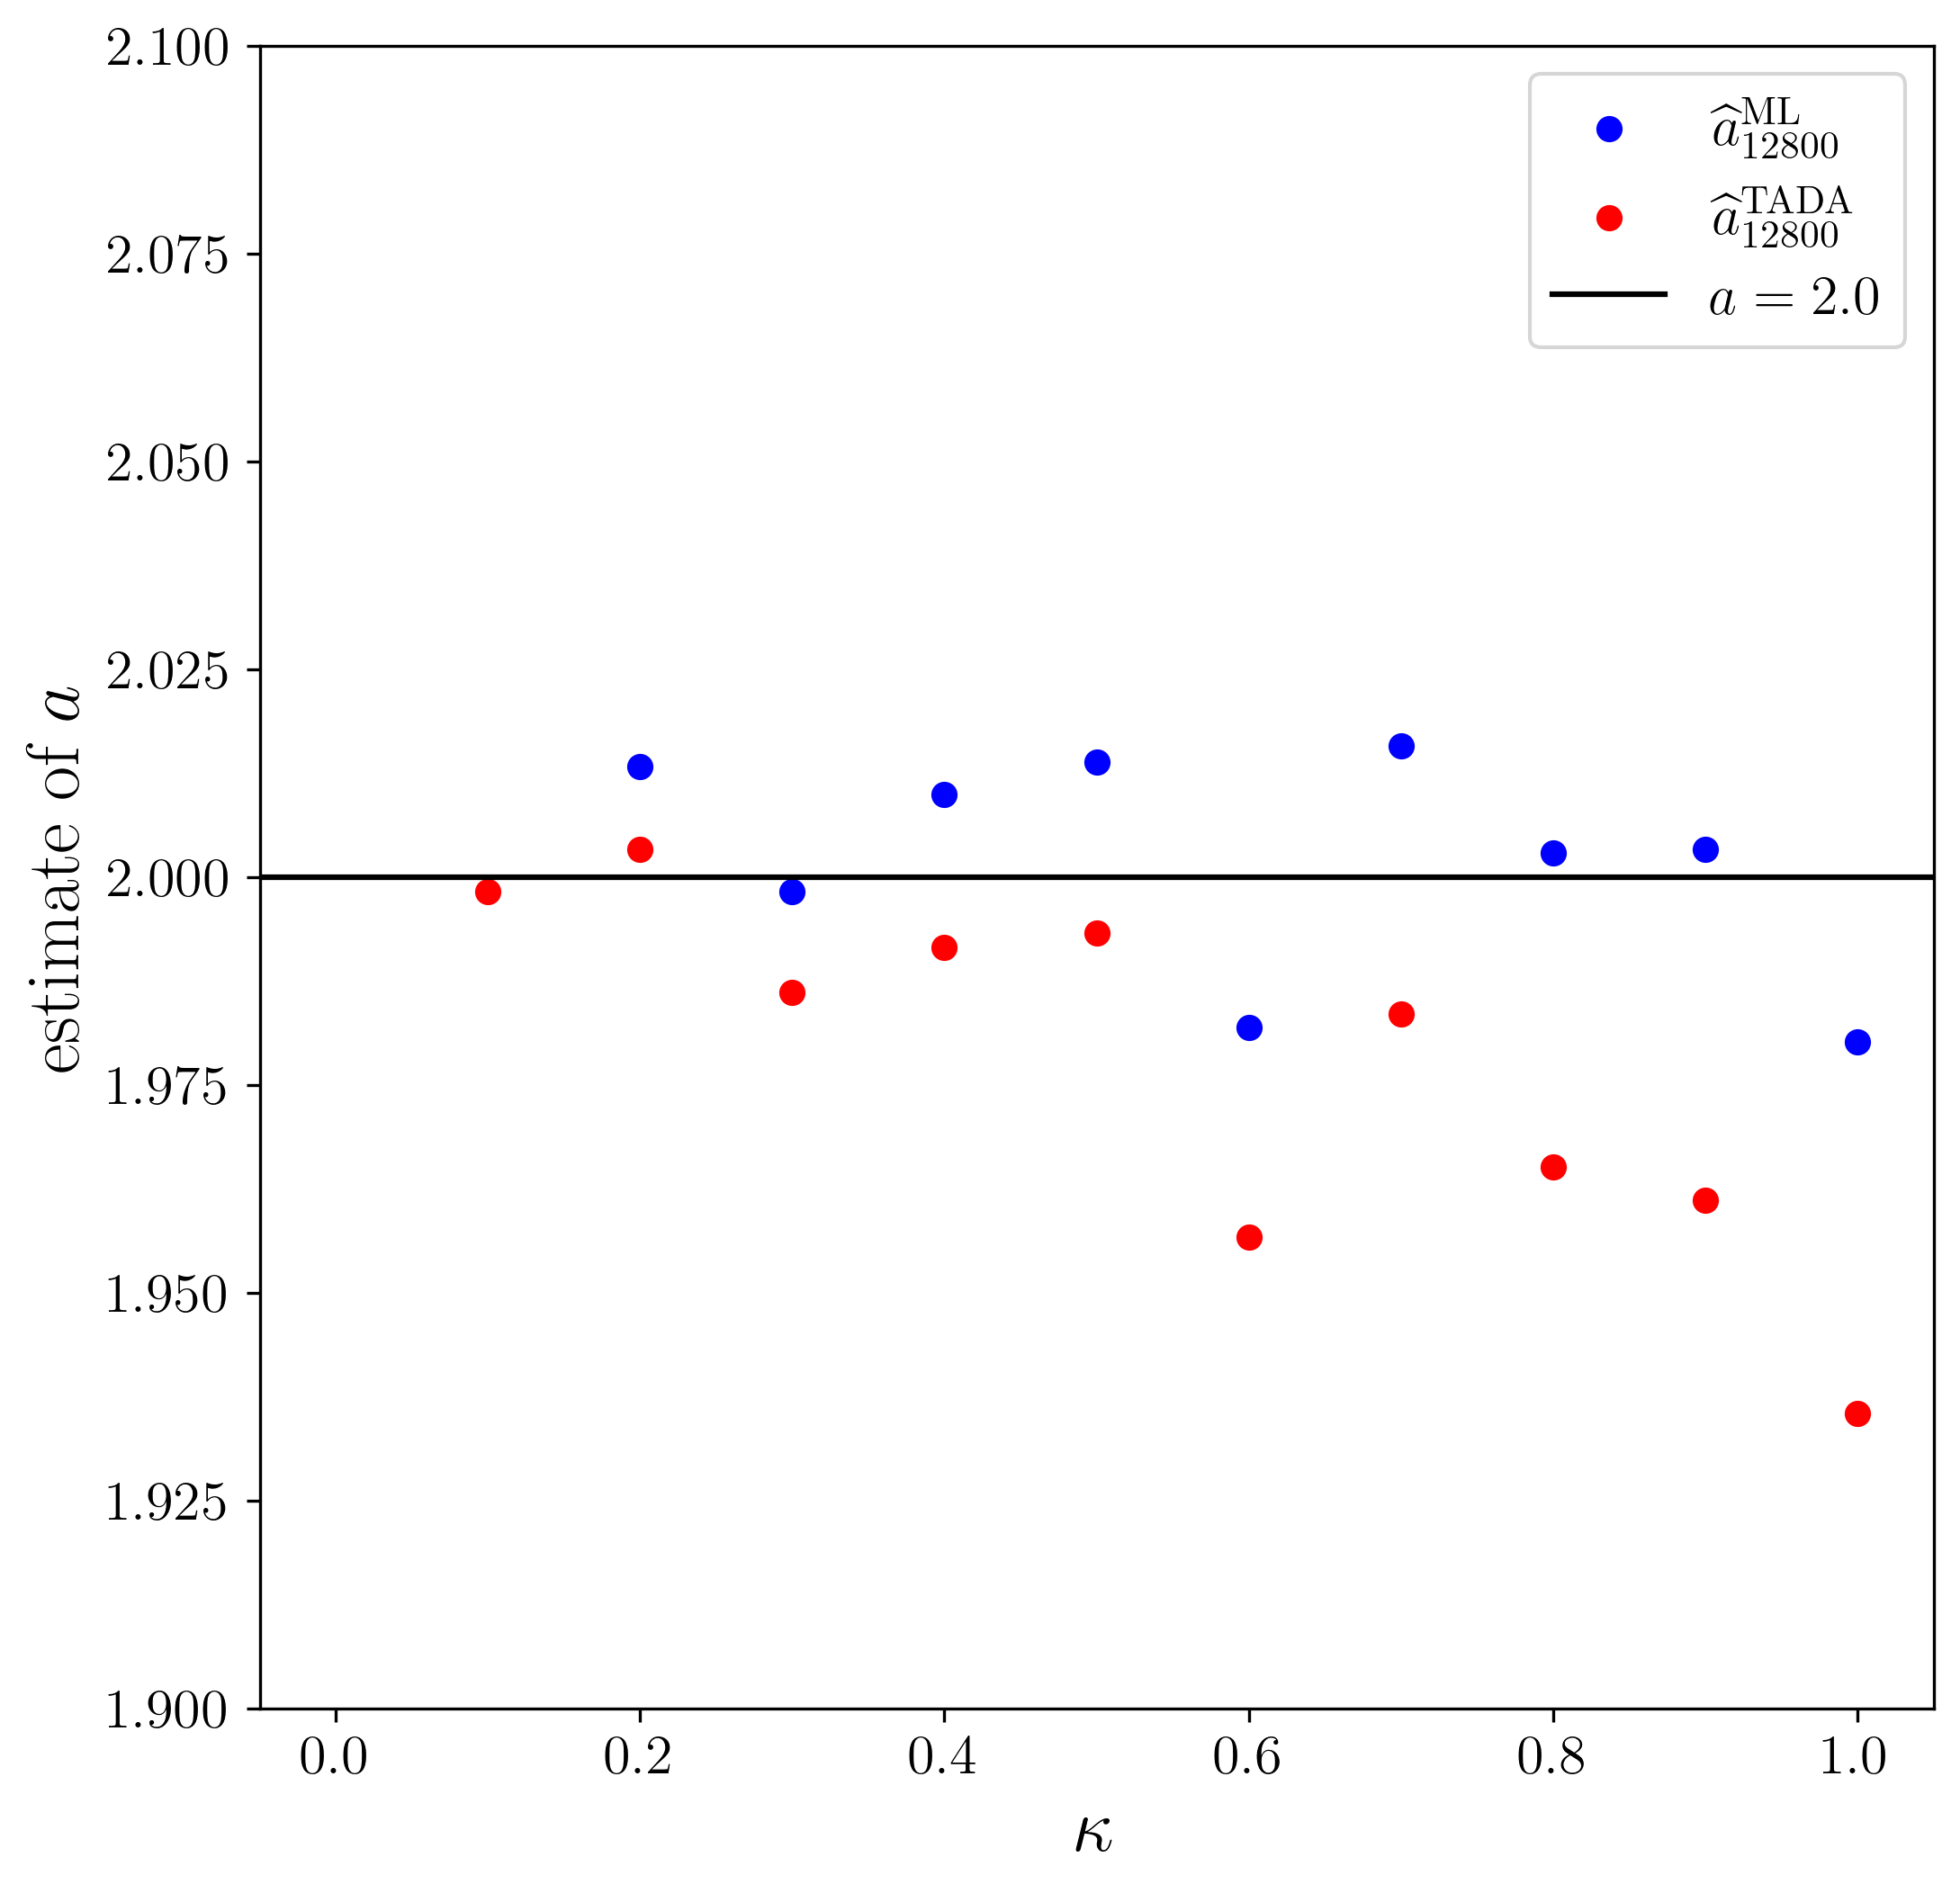

In [18]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_mle_arr[num_data_idx, :, 2],
    label=rf"$\widehat{{a}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_tada_arr[num_data_idx, :, 2],
    label=rf"$\widehat{{a}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 2], 0, 1, c="k", label=rf"$a={paras_true_arr[num_data_idx, 0, 2]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$\kappa$", fontsize=20)
ax.set_ylabel(r"estimate of $a$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-0.05, 1.05))
ax.set_ylim((1.9, 2.1))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

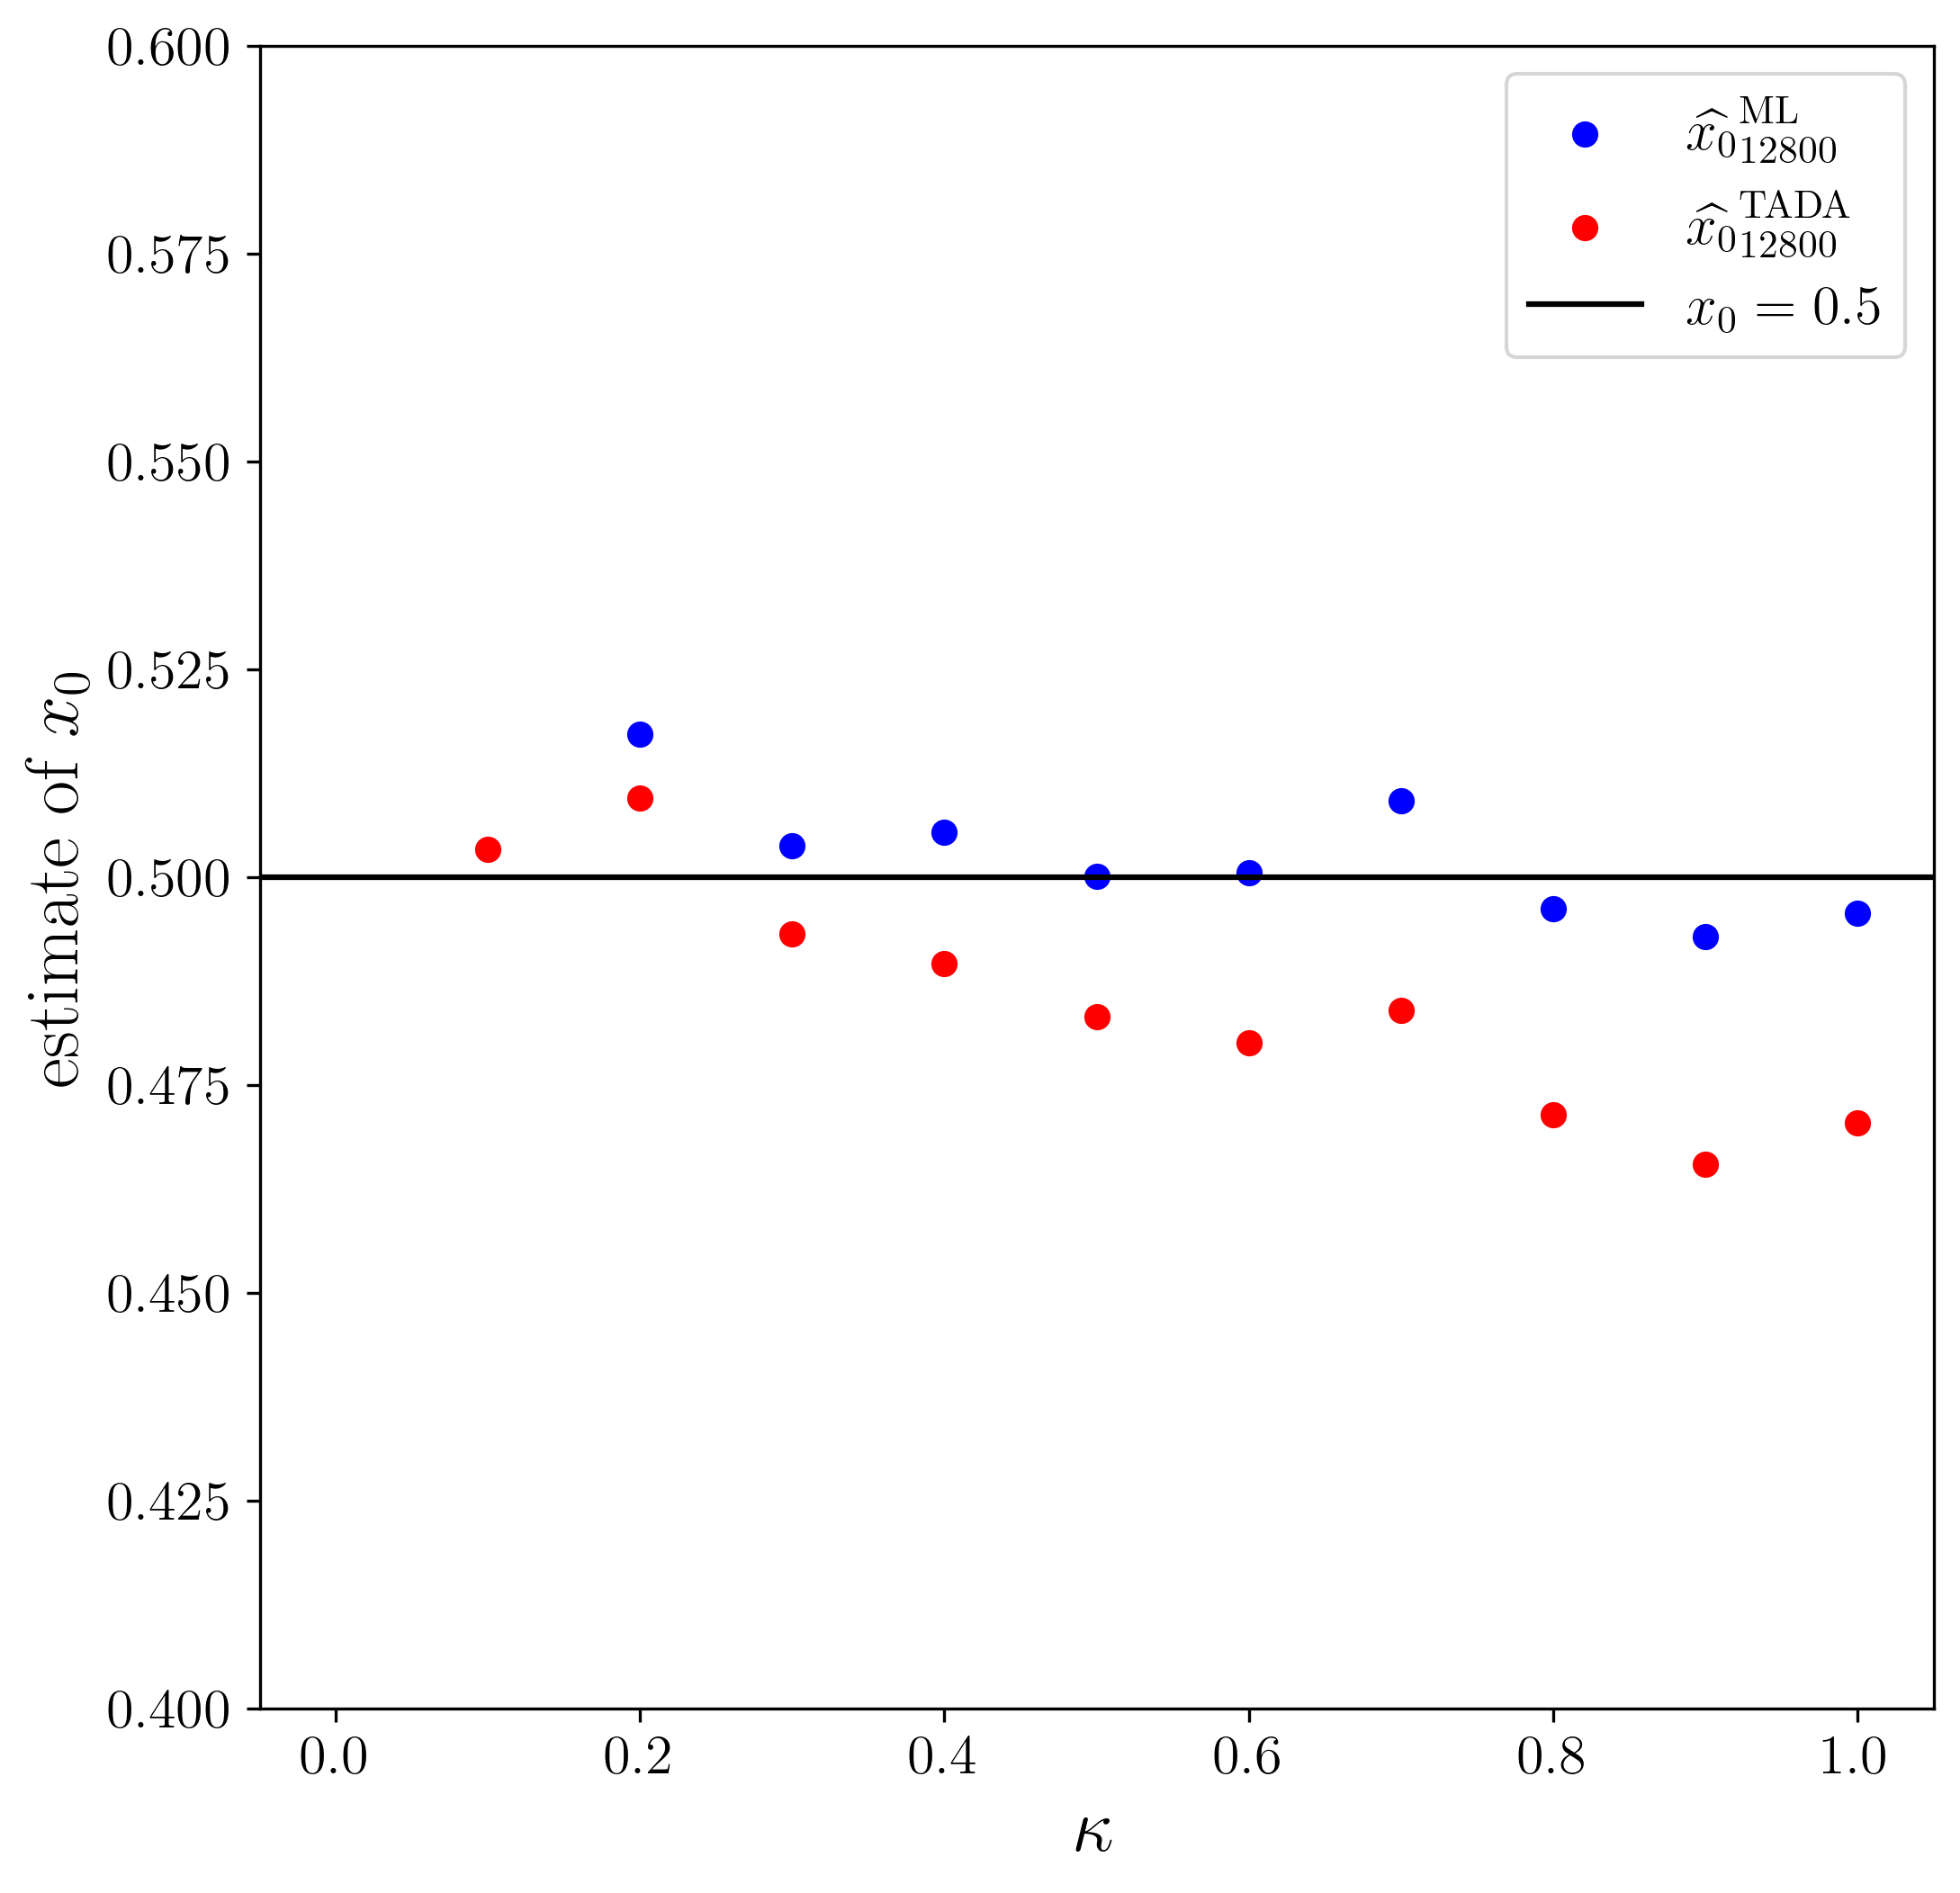

In [19]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_mle_arr[num_data_idx, :, 3],
    label=rf"$\widehat{{x_0}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 1],
    paras_tada_arr[num_data_idx, :, 3],
    label=rf"$\widehat{{x_0}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 3], 0, 1, c="k", label=rf"$x_0={paras_true_arr[num_data_idx, 0, 3]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$\kappa$", fontsize=20)
ax.set_ylabel(r"estimate of $x_0$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-0.05, 1.05))
ax.set_ylim((0.4, 0.6))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()